In [ ]:
!pip install kaggle --quiet

In [ ]:

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"petal2025","key":"c88a6e1381bcb3683557de000aaecce3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lainguyn123/student-performance-factors
!kaggle datasets download -d eldarsarajlic/college-enrollment-in-the-us-20032021
!kaggle datasets download -d raymondtoo/the-world-university-rankings-2016-2024
!kaggle datasets download -d thedevastator/higher-education-predictors-of-student-retention
!kaggle datasets download -d jeromeblanchet/drivendatas-boxplots-for-education-dataset

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
License(s): CC0-1.0
  0% 0.00/93.9k [00:00<?, ?B/s]
100% 93.9k/93.9k [00:00<00:00, 90.0MB/s]
Dataset URL: https://www.kaggle.com/datasets/eldarsarajlic/college-enrollment-in-the-us-20032021
License(s): unknown
  0% 0.00/819 [00:00<?, ?B/s]
100% 819/819 [00:00<00:00, 3.23MB/s]
Dataset URL: https://www.kaggle.com/datasets/raymondtoo/the-world-university-rankings-2016-2024
License(s): MIT
  0% 0.00/622k [00:00<?, ?B/s]
100% 622k/622k [00:00<00:00, 1.07GB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
License(s): CC0-1.0
  0% 0.00/87.2k [00:00<?, ?B/s]
100% 87.2k/87.2k [00:00<00:00, 197MB/s]
Dataset URL: https://www.kaggle.com/datasets/jeromeblanchet/drivendatas-boxplots-for-education-dataset
License(s): unknown
  0% 0.00/20.7M [00:00<?, ?B/s]
100% 20.7M/20.7M [00:00<00:00, 1.29GB/s]


In [ ]:
!unzip -q student-performance-factors.zip -d student_performance
!unzip -q college-enrollment-in-the-us-20032021.zip -d college_enrollment
!unzip -q the-world-university-rankings-2016-2024.zip -d university_rankings
!unzip -q higher-education-predictors-of-student-retention.zip -d retention
!unzip -q drivendatas-boxplots-for-education-dataset.zip -d education

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()


In [ ]:
%matplotlib inline

In [ ]:
# generic_accuracy_calculator.py
import time
import numpy as np
import pandas as pd
from typing import Dict, Any, Optional, List, Tuple

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

# Optional models
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


# -----------------------------
# Task detection
# -----------------------------
def detect_task_type(y: pd.Series) -> str:
    if y.dtype == "O" or str(y.dtype).startswith("category") or y.dtype == bool:
        return "Classification"
    nunique = y.nunique(dropna=True)
    if pd.api.types.is_integer_dtype(y) and nunique <= 20:
        return "Classification"
    return "Regression"


# -----------------------------
# Preprocessor
# -----------------------------
def build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),  # produces sparse by default
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
    )
    return pre, num_cols, cat_cols


def preprocess_data(
    df: pd.DataFrame,
    target_column: str,
    task_type: str = "auto",
    feature_columns: Optional[List[str]] = None,
    test_size: float = 0.2,
    random_state: int = 42,
):
    df = df.copy()
    # remove accidental index columns
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]

    # Strip column names to avoid "Value " vs "Value" issues
    df.columns = df.columns.astype(str).str.strip()

    if target_column not in df.columns:
        raise KeyError(f"target_column='{target_column}' not found. Available columns: {df.columns.tolist()}")

    X = df.drop(columns=[target_column]) if feature_columns is None else df[feature_columns]
    y = df[target_column]

    detected = detect_task_type(y) if task_type == "auto" else task_type

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    preprocessor, num_cols, cat_cols = build_preprocessor(X_train)

    return {
        "task_type": detected,
        "X_train_raw": X_train,
        "X_test_raw": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocessor": preprocessor,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
    }


# -----------------------------
# Models
# -----------------------------
def get_base_models(task_type: str) -> Dict[str, Any]:
    if task_type == "Regression":
        models = {
            "LinearRegression": LinearRegression(),
            "RandomForest": RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
            "HistGB": HistGradientBoostingRegressor(random_state=42),
        }
        if XGB_AVAILABLE:
            models["XGBoost"] = xgb.XGBRegressor(
                random_state=42,
                n_estimators=300,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.9,
                colsample_bytree=0.9,
            )
        if LGB_AVAILABLE:
            models["LightGBM"] = lgb.LGBMRegressor(
                random_state=42,
                n_estimators=400,
                learning_rate=0.06,
            )
        return models

    # Classification
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto"),
        "RandomForest": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1),
        "HistGB": HistGradientBoostingClassifier(random_state=42),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(
            random_state=42,
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
        )
    if LGB_AVAILABLE:
        models["LightGBM"] = lgb.LGBMClassifier(
            random_state=42,
            n_estimators=400,
            learning_rate=0.06,
        )
    return models


def get_search_spaces(task_type: str) -> Dict[str, Dict[str, List[Any]]]:
    if task_type == "Regression":
        spaces = {
            "RandomForest": {
                "model__n_estimators": [200, 400, 800],
                "model__max_depth": [None, 8, 12, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
            "HistGB": {
                "model__max_depth": [None, 6, 10],
                "model__learning_rate": [0.03, 0.06, 0.1],
                "model__max_iter": [200, 400, 800],
                "model__min_samples_leaf": [10, 20, 50],
            },
        }
        if XGB_AVAILABLE:
            spaces["XGBoost"] = {
                "model__n_estimators": [200, 300, 500],
                "model__max_depth": [3, 4, 6],
                "model__learning_rate": [0.03, 0.06, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        if LGB_AVAILABLE:
            spaces["LightGBM"] = {
                "model__n_estimators": [200, 400, 800],
                "model__num_leaves": [31, 63, 127],
                "model__learning_rate": [0.03, 0.06, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        return spaces

    # Classification
    spaces = {
        "LogisticRegression": {
            "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs", "saga"],
        },
        "RandomForest": {
            "model__n_estimators": [200, 400, 800],
            "model__max_depth": [None, 8, 12, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        },
        "HistGB": {
            "model__max_depth": [None, 6, 10],
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__max_iter": [200, 400, 800],
            "model__min_samples_leaf": [10, 20, 50],
        },
    }
    if XGB_AVAILABLE:
        spaces["XGBoost"] = {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [3, 4, 6],
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    if LGB_AVAILABLE:
        spaces["LightGBM"] = {
            "model__n_estimators": [200, 400, 800],
            "model__num_leaves": [31, 63, 127],
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    return spaces


# -----------------------------
# Metrics
# -----------------------------
def safe_mape(y_true, y_pred) -> float:
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    mask = (y_true != 0)
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def calculate_all_metrics(y_true, y_pred, task_type: str) -> Dict[str, float]:
    out = {}
    if task_type == "Regression":
        y_true_f = np.array(y_true).astype(float)
        y_pred_f = np.array(y_pred).astype(float)
        out["MAE"] = float(mean_absolute_error(y_true_f, y_pred_f))
        out["RMSE"] = float(mean_squared_error(y_true_f, y_pred_f))
        out["MAPE"] = float(safe_mape(y_true_f, y_pred_f))
        out["R2"] = float(r2_score(y_true_f, y_pred_f))
        return out

    # Classification
    out["Accuracy"] = float(accuracy_score(y_true, y_pred))
    out["F1"] = float(f1_score(y_true, y_pred, average="weighted"))
    out["Precision"] = float(precision_score(y_true, y_pred, average="weighted", zero_division=0))
    out["Recall"] = float(recall_score(y_true, y_pred, average="weighted", zero_division=0))

    # Optional numeric-error metrics on encoded labels (requested previously)
    y_true_s = pd.Series(y_true)
    y_pred_s = pd.Series(y_pred)
    if y_true_s.dtype == "O" or str(y_true_s.dtype).startswith("category"):
        all_cats = pd.Index(pd.unique(y_true_s.astype(str)))
        map_ = {k: i for i, k in enumerate(all_cats)}
        yt = y_true_s.astype(str).map(map_).astype(float).values
        yp = y_pred_s.astype(str).map(map_).fillna(0).astype(float).values
    else:
        yt = y_true_s.astype(float).values
        yp = y_pred_s.astype(float).values

    out["MAE"] = float(mean_absolute_error(yt, yp))
    out["RMSE"] = float(mean_squared_error(yt, yp))
    out["MAPE"] = float(safe_mape(yt, yp))
    return out


# -----------------------------
# Dense converter (fix for HistGB)
# -----------------------------
def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X


# -----------------------------
# Train baseline + tuned
# -----------------------------
def train_and_evaluate_models(
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    y_train,
    y_test,
    preprocessor: ColumnTransformer,
    task_type: str,
    do_hyperparam_tuning: bool = True,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names: Optional[List[str]] = None,
) -> Dict[str, Any]:

    base_models = get_base_models(task_type)
    if model_names is not None:
        base_models = {k: v for k, v in base_models.items() if k in set(model_names)}

    spaces = get_search_spaces(task_type)

    results = {
        "baseline": {},
        "tuned": {},
        "best_params": {},
        "best_cv": {},
        "pipelines": {},
    }

    for name, model in base_models.items():

        # ✅ IMPORTANT FIX:
        # HistGradientBoosting models require dense inputs
        force_dense = (name == "HistGB") or ("HistGradientBoosting" in model.__class__.__name__)

        steps = [("preprocess", preprocessor)]
        if force_dense:
            steps.append(("to_dense", FunctionTransformer(_to_dense, validate=False, accept_sparse=True)))
        steps.append(("model", model))
        pipe = Pipeline(steps=steps)

        # baseline fit
        t0 = time.time()
        pipe.fit(X_train_raw, y_train)
        train_time = time.time() - t0

        # inference timing
        t1 = time.time()
        y_pred = pipe.predict(X_test_raw)
        infer_time = (time.time() - t1) / max(1, len(X_test_raw)) * 1000.0  # ms/sample

        m = calculate_all_metrics(y_test, y_pred, task_type)
        m["TrainTime(s)"] = float(train_time)
        m["Inference(ms/sample)"] = float(infer_time)
        results["baseline"][name] = m

        # tuning
        if do_hyperparam_tuning and name in spaces:
            scoring = "r2" if task_type == "Regression" else "accuracy"
            search = RandomizedSearchCV(
                pipe,
                param_distributions=spaces[name],
                n_iter=tuning_n_iter,
                cv=tuning_cv,
                scoring=scoring,
                n_jobs=-1,
                random_state=42,
                verbose=0,
            )
            t0 = time.time()
            search.fit(X_train_raw, y_train)
            tuned_pipe = search.best_estimator_
            tuned_train_time = time.time() - t0

            t1 = time.time()
            y_pred2 = tuned_pipe.predict(X_test_raw)
            tuned_infer_time = (time.time() - t1) / max(1, len(X_test_raw)) * 1000.0

            m2 = calculate_all_metrics(y_test, y_pred2, task_type)
            m2["TrainTime(s)"] = float(tuned_train_time)
            m2["Inference(ms/sample)"] = float(tuned_infer_time)

            results["tuned"][name] = m2
            results["best_params"][name] = search.best_params_
            results["best_cv"][name] = float(search.best_score_)
            results["pipelines"][name] = tuned_pipe
        else:
            results["tuned"][name] = results["baseline"][name]
            results["best_params"][name] = None
            results["best_cv"][name] = None
            results["pipelines"][name] = pipe

    return results


In [ ]:
# vertexML.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

shap.initjs()

from typing import Optional, Dict, Any, List

# from generic_accuracy_calculator import (
#     preprocess_data,
#     train_and_evaluate_models,
# )

READINESS_WEIGHTS_DEFAULT = {
    "Accuracy": 0.25,
    "Fairness": 0.20,
    "Interpretability": 0.20,
    "DataQuality": 0.20,
    "Scalability": 0.15,
}

def data_quality_score(X_raw: pd.DataFrame) -> float:
    total = X_raw.size
    miss = X_raw.isna().sum().sum()
    missing_ratio = 0.0 if total == 0 else miss / total
    score = 5.0 * (1.0 - min(1.0, 2.0 * missing_ratio))
    return float(max(0.0, min(5.0, score)))

def interpretability_score_from_shap(mean_abs_vals: np.ndarray) -> float:
    v = np.array(mean_abs_vals, dtype=float)
    v = np.abs(v)
    s = v.sum()
    if s <= 0:
        return 0.0
    p = v / s
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    conc = 1.0 - (entropy / max_entropy if max_entropy > 0 else 0.0)
    return float(max(0.0, min(5.0, 5.0 * conc)))

def fairness_score_from_shap_bins(shap_2d: np.ndarray, preds: np.ndarray, K: int = 4) -> float:
    sv = np.array(shap_2d, dtype=float)
    preds = np.array(preds).reshape(-1)

    # ✅ align lengths (SHAP often uses a sample, preds might be full test)
    n = min(len(preds), sv.shape[0])
    if n < 10:
        return 2.5

    sv = sv[:n]
    preds = preds[:n]

    # quantile bins on aligned preds
    qs = np.quantile(preds, np.linspace(0, 1, K + 1))
    bins = []
    for k in range(K):
        mask = (preds >= qs[k]) & (preds <= qs[k+1] if k == K-1 else preds < qs[k+1])
        idx = np.where(mask)[0]
        if len(idx) > 0:
            bins.append(idx)

    if len(bins) < 2:
        return 2.5

    mus = [np.mean(np.abs(sv[idx]), axis=0) for idx in bins]

    dsum = 0.0
    cnt = 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            dsum += float(np.mean(np.abs(mus[i] - mus[j])))
            cnt += 1

    div = dsum / max(1, cnt)
    score = 5.0 * (1.0 / (1.0 + 10.0 * div))
    return float(max(0.0, min(5.0, score)))


def scalability_score(train_time_s: float, infer_ms_per_sample: float) -> float:
    def f(t):
        return float(max(0.0, min(5.0, 5.0 - np.log10(1.0 + max(0.0, t)) * 1.5)))
    train_component = f(train_time_s)
    infer_component = f(infer_ms_per_sample / 1000.0)
    return float(0.6 * train_component + 0.4 * infer_component)

def _shap_to_2d(shap_values, task_type: str):
    if isinstance(shap_values, list):
        arrs = [np.array(a) for a in shap_values if a is not None]
        if len(arrs) == 0:
            return None
        arrs2 = []
        for a in arrs:
            if a.ndim == 2:
                arrs2.append(a)
            elif a.ndim == 3:
                arrs2.append(a[:, :, -1])
            else:
                arrs2.append(a.reshape(a.shape[0], -1))
        if len(arrs2) == 2 and task_type != "Regression":
            return arrs2[1]
        return np.mean(np.stack(arrs2, axis=2), axis=2)

    sv = np.array(shap_values)
    if sv.ndim == 3:
        if task_type != "Regression" and sv.shape[2] >= 2:
            return sv[:, :, -1]
        return np.mean(sv, axis=2)
    if sv.ndim == 2:
        return sv
    if sv.ndim == 1:
        return sv.reshape(-1, 1)
    return None

def _base_feature_name(n: str) -> str:
    n = str(n)
    for pref in ("num__", "cat__", "remainder__", "num_", "cat_"):
        if n.startswith(pref):
            n = n[len(pref):]
    if "_" in n:
        return n.split("_", 1)[0]
    return n

def perform_shap_analysis_pipeline_model(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    shap_out_dir: str = "shap_outputs",
    shap_sample_size: int = 200,
):
    os.makedirs(shap_out_dir, exist_ok=True)
    print(f"\nRunning SHAP for: {model_name}\n")

    try:
        X_test_s = X_test_raw.sample(n=min(shap_sample_size, len(X_test_raw)), random_state=42).copy()
        X_train_s = X_train_raw.sample(n=min(200, len(X_train_raw)), random_state=42).copy()

        est = trained_pipeline.named_steps["model"]
        pre = trained_pipeline.named_steps["preprocess"]

        # Tree models -> TreeExplainer
        is_tree = any(t in est.__class__.__name__ for t in ["RandomForest", "XGB", "LGBM"])
        # HistGB often fails with TreeExplainer, use fallback explainer for it
        if "HistGradientBoosting" in est.__class__.__name__:
            is_tree = False

        if is_tree:
            Xt = pre.transform(X_test_s)
            Xt_dense = Xt.toarray() if hasattr(Xt, "toarray") else Xt

            explainer = shap.TreeExplainer(est)
            shap_values = explainer.shap_values(Xt_dense, check_additivity=False)
            sv_plot = _shap_to_2d(shap_values, task_type)
            if sv_plot is None:
                raise ValueError("Unsupported SHAP shape")

            try:
                feat_names = pre.get_feature_names_out()
            except Exception:
                feat_names = [f"feature_{i}" for i in range(sv_plot.shape[1])]
            base_names = [_base_feature_name(n) for n in feat_names]

            plt.figure()
            shap.summary_plot(sv_plot, features=Xt_dense, feature_names=base_names, show=False)
            plt.tight_layout()
            plt.savefig(os.path.join(shap_out_dir, f"shap_{model_name}_summary.png"), dpi=200, bbox_inches="tight")
            plt.show()

        else:
            Xt_test = pre.transform(X_test_s)
            Xt_train = pre.transform(X_train_s)

            Xt_test_dense = Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test
            Xt_train_dense = Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train

    # Try to get feature names from preprocessor
            try:
                feat_names = pre.get_feature_names_out()
            except Exception:
                feat_names = [f"feature_{i}" for i in range(Xt_test_dense.shape[1])]

            base_names = [_base_feature_name(n) for n in feat_names]

            f = est.predict_proba if (task_type != "Regression" and hasattr(est, "predict_proba")) else est.predict
            masker = shap.maskers.Independent(Xt_train_dense)
            explainer = shap.Explainer(f, masker)
            exp = explainer(Xt_test_dense)

            sv_plot = _shap_to_2d(exp.values, task_type)
            if sv_plot is None:
                raise ValueError("Unsupported SHAP shape")

            # Fallback explainer for LogisticRegression + HistGB + any unsupported model
            # f = trained_pipeline.predict_proba if (task_type != "Regression" and hasattr(trained_pipeline, "predict_proba")) else trained_pipeline.predict
            # masker = shap.maskers.Independent(X_train_s)
            # explainer = shap.Explainer(f, masker)
            # exp = explainer(X_test_s)

            # sv_plot = _shap_to_2d(exp.values, task_type)
            # if sv_plot is None:
            #     raise ValueError("Unsupported SHAP shape")
            # base_names = list(X_test_s.columns)

        mean_abs = np.mean(np.abs(sv_plot), axis=0)
        if getattr(mean_abs, "ndim", 1) != 1:
            mean_abs = np.mean(mean_abs, axis=-1)

        agg = {}
        for n, v in zip(base_names, mean_abs):
            b = _base_feature_name(n)
            if str(b).startswith("Unnamed"):
                continue
            agg[b] = agg.get(b, 0.0) + float(v)

        top = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)[:20]
        top_names = [k for k, _ in top][::-1]
        top_vals = [v for _, v in top][::-1]

        plt.figure()
        plt.barh(top_names, top_vals)
        plt.title(f"Top 20 SHAP Features (aggregated) - {model_name}")
        plt.xlabel("Mean(|SHAP value|)")
        plt.tight_layout()
        plt.savefig(os.path.join(shap_out_dir, f"shap_{model_name}_bar.png"), dpi=200, bbox_inches="tight")
        plt.show()

        return {"shap_2d": sv_plot, "mean_abs": mean_abs, "top_features": top}

    except Exception as e:
        print(f"  ⚠️ SHAP failed: {e}")
        return None


def _print_before_after(model_name: str, before: Dict[str, Any], after: Dict[str, Any], best_params, best_cv):
    print(f"\nModel: {model_name}")

    if "Accuracy" in before:
        print(f"  Accuracy : {before.get('Accuracy')}  ->  {after.get('Accuracy')}")
        print(f"  F1       : {before.get('F1')}  ->  {after.get('F1')}")
    else:
        print(f"  R2   : {before.get('R2')}  ->  {after.get('R2')}")
        print(f"  MAE  : {before.get('MAE')} ->  {after.get('MAE')}")
        print(f"  RMSE : {before.get('RMSE')} ->  {after.get('RMSE')}")
        print(f"  MAPE : {before.get('MAPE')} ->  {after.get('MAPE')}")

    print(f"  TrainTime(s): {before.get('TrainTime(s)')} -> {after.get('TrainTime(s)')}")
    print(f"  Inference(ms/sample): {before.get('Inference(ms/sample)')} -> {after.get('Inference(ms/sample)')}")

    if best_params is not None:
        print(f"  ✅ Best Params : {best_params}")
        print(f"  ✅ Best CV     : {best_cv}")


def comprehensive_ml_pipeline(
    dataset_path,
    target_column,
    task_type="auto",
    demographic_column=None,
    readiness_sub_weights=None,
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names: Optional[List[str]] = None,
    shap_sample_size: int = 200,
    fast_mode: str = "auto",
    feature_columns=None,
    max_tfidf_features: int = 10000,
    shap_out_dir: str = "shap_outputs",
):
    print("\n" + "="*90)
    print("COMPREHENSIVE ML PIPELINE")
    print("="*90)

    df = pd.read_csv(dataset_path) if isinstance(dataset_path, str) else dataset_path.copy()
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]
    df.columns = df.columns.astype(str).str.strip()

    prep = preprocess_data(df, target_column, task_type, feature_columns)
    detected_task = prep["task_type"]
    X_train_raw = prep["X_train_raw"]
    X_test_raw = prep["X_test_raw"]
    y_train = prep["y_train"]
    y_test = prep["y_test"]
    preprocessor = prep["preprocessor"]

    print(f"\nTask type detected: {detected_task}")
    print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

    # Fast mode: keep LogisticRegression for classification
    if model_names is None and fast_mode in ("auto", "always"):
        big = (len(df) > 20000) or (X_train_raw.shape[1] > 150)
        if big:
            if detected_task == "Classification":
                model_names = ["LogisticRegression", "HistGB", "LightGBM"]
            else:
                model_names = ["HistGB", "LightGBM"]

    train_res = train_and_evaluate_models(
        X_train_raw=X_train_raw,
        X_test_raw=X_test_raw,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor,
        task_type=detected_task,
        do_hyperparam_tuning=do_hyperparam_tuning,
        tuning_n_iter=tuning_n_iter,
        tuning_cv=tuning_cv,
        model_names=model_names,
    )

    print("\n" + "="*90)
    print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
    print("="*90)

    for mname in train_res["baseline"].keys():
        _print_before_after(
            mname,
            train_res["baseline"][mname],
            train_res["tuned"][mname],
            train_res["best_params"].get(mname),
            train_res["best_cv"].get(mname),
        )

    shap_results = {}
    readiness = {}

    X_all_raw = df.drop(columns=[target_column]) if feature_columns is None else df[feature_columns]
    dq = data_quality_score(X_all_raw)

    for mname, pipe in train_res["pipelines"].items():
        shap_res = None
        interp = 2.5
        fair = 2.5

        if compute_shap:
            shap_res = perform_shap_analysis_pipeline_model(
                trained_pipeline=pipe,
                X_train_raw=X_train_raw,
                X_test_raw=X_test_raw,
                model_name=mname,
                task_type=detected_task,
                shap_out_dir=shap_out_dir,
                shap_sample_size=shap_sample_size,
            )
            shap_results[mname] = shap_res
            if shap_res is not None:
                interp = interpretability_score_from_shap(shap_res["mean_abs"])
                preds = pipe.predict(X_test_raw)
                try:
                    preds = np.array(preds, dtype=float)
                except Exception:
                    preds = pd.Series(preds).astype("category").cat.codes.values.astype(float)
                fair = fairness_score_from_shap_bins(shap_res["shap_2d"], preds, K=4)

        tuned_metrics = train_res["tuned"][mname]
        if detected_task == "Regression":
            acc_component = tuned_metrics.get("R2", 0.0)
            acc_score = float(max(0.0, min(5.0, 5.0 * max(0.0, acc_component))))
        else:
            acc_component = tuned_metrics.get("Accuracy", 0.0)
            acc_score = float(max(0.0, min(5.0, 5.0 * acc_component)))

        sc = scalability_score(
            tuned_metrics.get("TrainTime(s)", 0.0),
            tuned_metrics.get("Inference(ms/sample)", 0.0),
        )

        w = READINESS_WEIGHTS_DEFAULT if readiness_sub_weights is None else readiness_sub_weights
        final = (
            w["Accuracy"] * acc_score
            + w["Fairness"] * fair
            + w["Interpretability"] * interp
            + w["DataQuality"] * dq
            + w["Scalability"] * sc
        )

        readiness[mname] = {
            "AccuracyScore(0-5)": acc_score,
            "Fairness(0-5)": float(fair),
            "Interpretability(0-5)": float(interp),
            "DataQuality(0-5)": float(dq),
            "Scalability(0-5)": float(sc),
            "Readiness(0-5)": float(final),
        }


    print("\n" + "="*90)
    print("📊 READINESS SCORE (0–5) PER MODEL — factor breakdown")
    print("="*90)

    w = READINESS_WEIGHTS_DEFAULT if readiness_sub_weights is None else readiness_sub_weights
    print("\nWeights used:")
    for k, v in w.items():
        print(f"  {k}: {v}")


    for mname, r in readiness.items():
        print(f"\nModel: {mname}")
        print(f"  AccuracyScore(0-5)      : {r.get('AccuracyScore(0-5)'):.4f}")
        print(f"  Fairness(0-5)           : {r.get('Fairness(0-5)'):.4f}")
        print(f"  Interpretability(0-5)   : {r.get('Interpretability(0-5)'):.4f}")
        print(f"  DataQuality(0-5)        : {r.get('DataQuality(0-5)'):.4f}")
        print(f"  Scalability(0-5)        : {r.get('Scalability(0-5)'):.4f}")
        print(f"  ✅ FINAL Readiness(0-5)  : {r.get('Readiness(0-5)'):.4f}")


    return {
        "task_type_detected": detected_task,
        "metrics_baseline": train_res["baseline"],
        "metrics_tuned": train_res["tuned"],
        "best_params": train_res["best_params"],
        "best_cv": train_res["best_cv"],
        "models_used": list(train_res["tuned"].keys()),
        "shap": shap_results,
        "readiness": readiness,
    }



COMPREHENSIVE ML PIPELINE

Task type detected: Regression
Train shape: (1973, 6), Test shape: (494, 6)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 1973, number of used features: 49
[LightGBM] [Info] Start training from score 3326854.939261
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 1973, number of used features: 49
[LightGBM] [Info] Start training from score 3326854.939261
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

PermutationExplainer explainer: 201it [00:44,  3.40it/s]


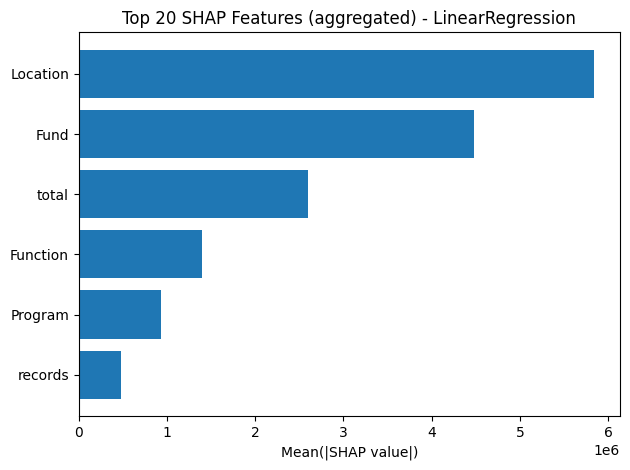


Running SHAP for: RandomForest



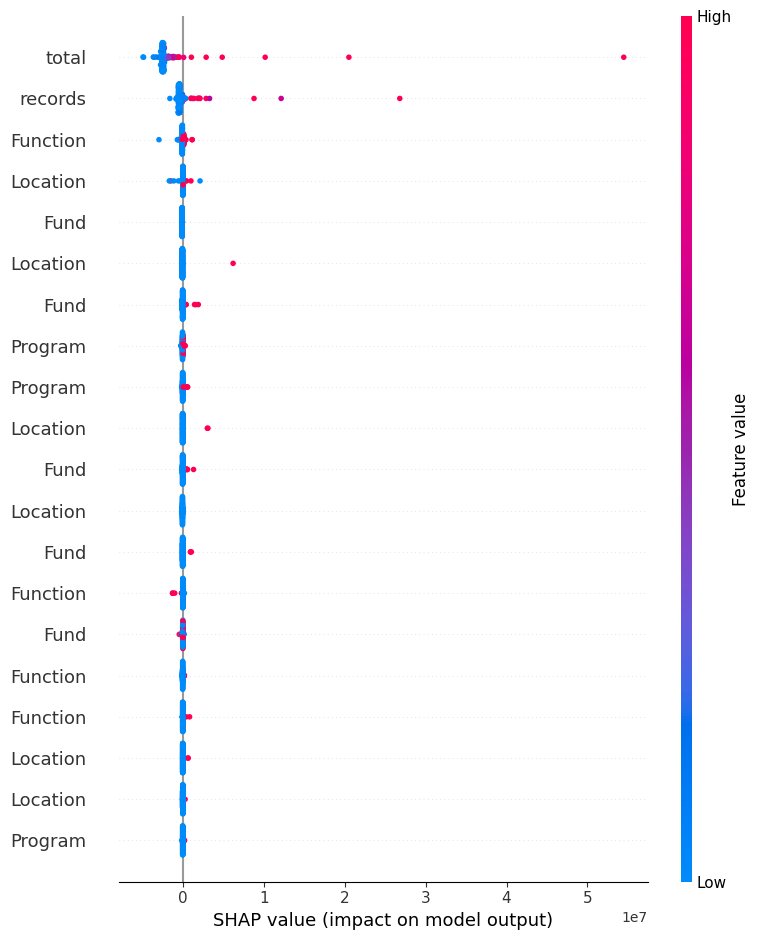

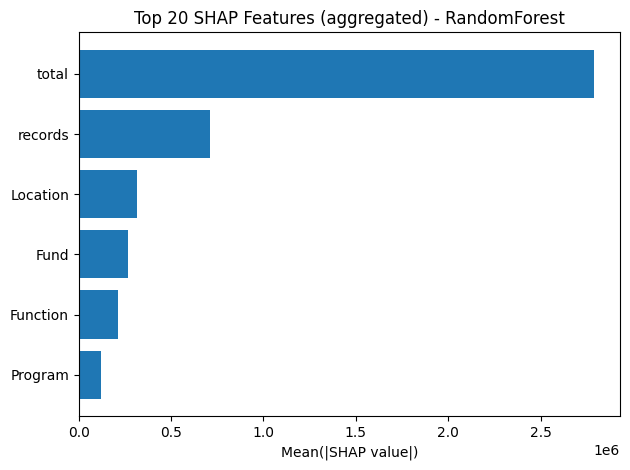


Running SHAP for: HistGB



PermutationExplainer explainer: 201it [01:35,  1.87it/s]


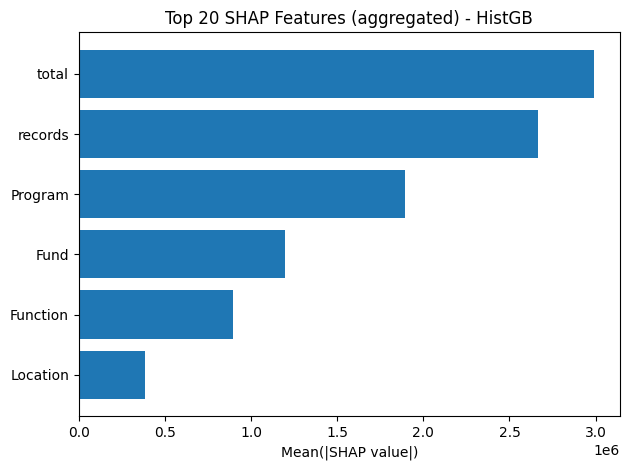


Running SHAP for: XGBoost



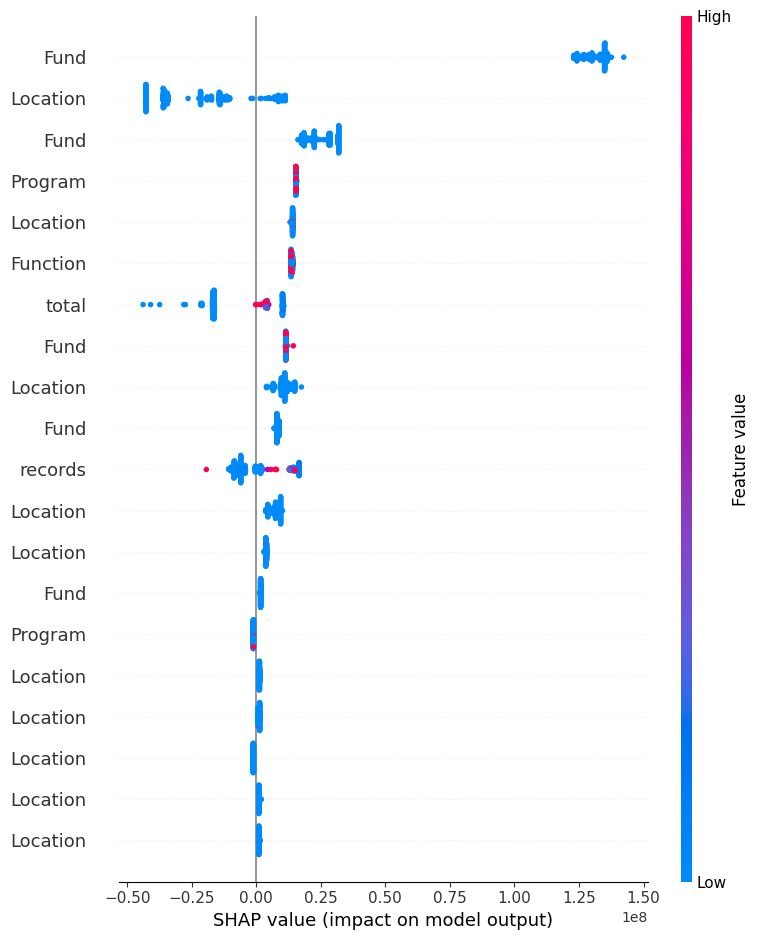

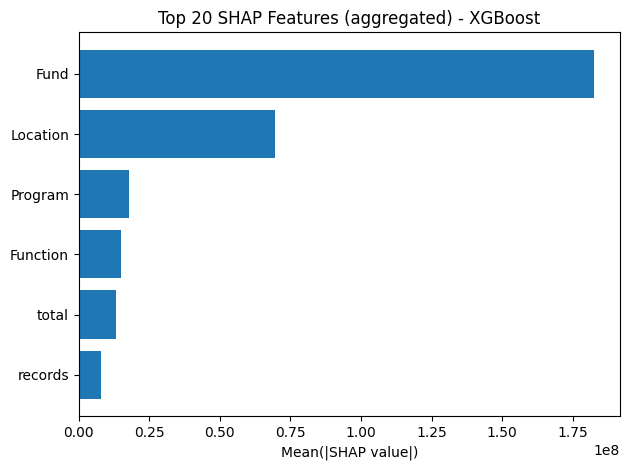


Running SHAP for: LightGBM



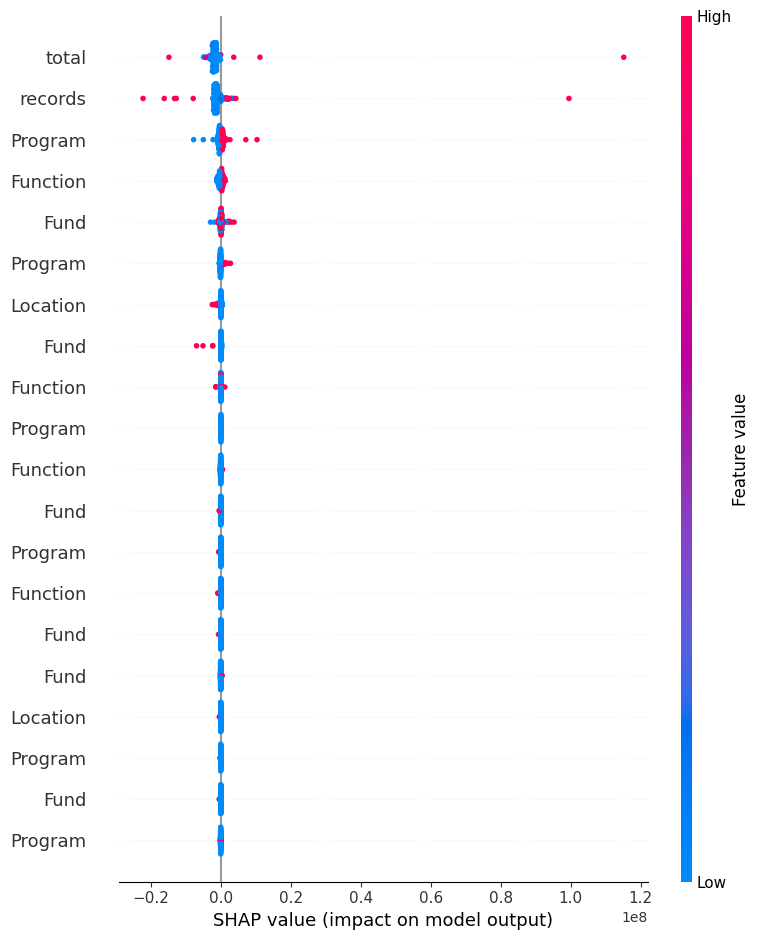

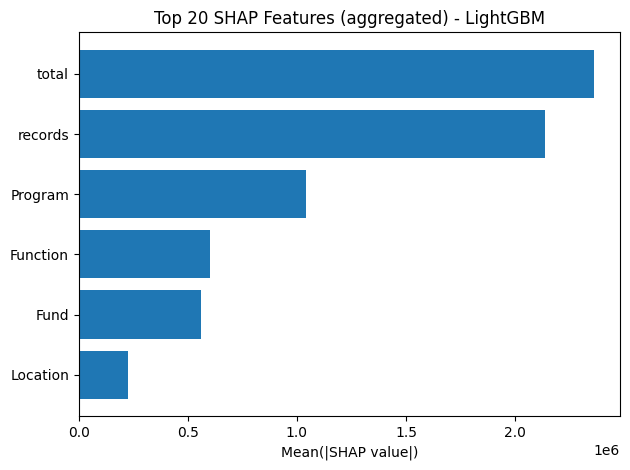


📊 READINESS SCORE (0–5) PER MODEL — factor breakdown

Weights used:
  Accuracy: 0.25
  Fairness: 0.2
  Interpretability: 0.2
  DataQuality: 0.2
  Scalability: 0.15

Model: LinearRegression
  AccuracyScore(0-5)      : 0.8251
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 1.7020
  DataQuality(0-5)        : 4.3697
  Scalability(0-5)        : 4.9821
  ✅ FINAL Readiness(0-5)  : 2.1679

Model: RandomForest
  AccuracyScore(0-5)      : 0.8729
  Fairness(0-5)           : 0.0003
  Interpretability(0-5)   : 3.7710
  DataQuality(0-5)        : 4.3697
  Scalability(0-5)        : 3.2543
  ✅ FINAL Readiness(0-5)  : 2.3345

Model: HistGB
  AccuracyScore(0-5)      : 0.0000
  Fairness(0-5)           : 0.0001
  Interpretability(0-5)   : 3.5172
  DataQuality(0-5)        : 4.3697
  Scalability(0-5)        : 3.3423
  ✅ FINAL Readiness(0-5)  : 2.0787

Model: XGBoost
  AccuracyScore(0-5)      : 0.3606
  Fairness(0-5)           : 0.0000
  Interpretability(0-5)   : 3.2132
  DataQuality(0-5)     

In [ ]:
results_budget = comprehensive_ml_pipeline(
    dataset_path="/content/budgetDataset.csv",
    target_column="total_budget",
    task_type="auto",
    fast_mode="auto",
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False
)